In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [13]:
df = pd.read_csv("/content/loan_prediction.csv")

In [14]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
df.shape

(614, 13)

In [16]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [18]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [19]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [20]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [21]:
df["Loan_Status"].value_counts(normalize=True) * 100

,proportion
Loan_Status,
Y,68.729642
N,31.270358


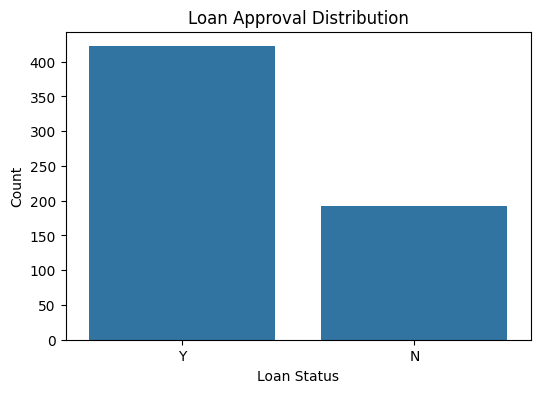

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [23]:
for col in ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Status']:
    print("="*40)
    print(col)
    print(df[col].value_counts(dropna=False))

Gender
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64
Married
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64
Dependents
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64
Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64
Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [24]:


df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)



df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [25]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [26]:
df.drop("Loan_ID", axis=1, inplace=True)

In [27]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
  df[col] = le.fit_transform(df[col])
print("categorical columns encoded successfully!")


categorical columns encoded successfully!


In [29]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [30]:
df.dtypes


,0
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


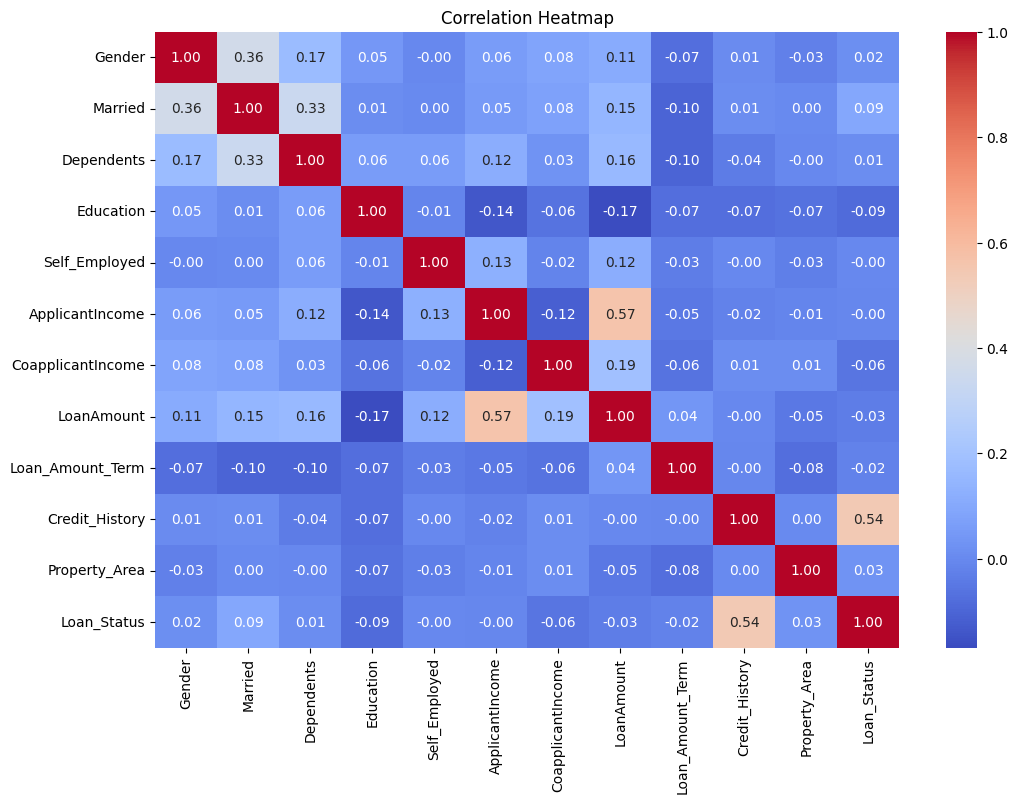

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Credit History is the most influential feature in predicting loan approval

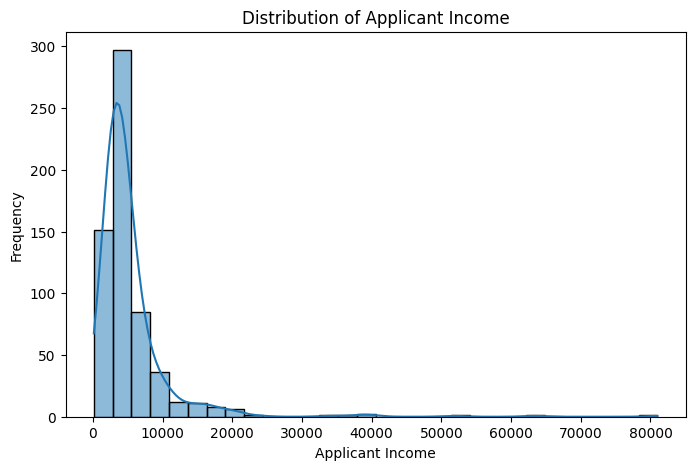

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["ApplicantIncome"],
             bins=30,
             kde=True)

plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

In [33]:
df["ApplicantIncome"].describe()

,ApplicantIncome
count,614.000000
mean,5403.459283
std,6109.041673
min,150.000000
25%,2877.500000
50%,3812.500000
75%,5795.000000
max,81000.000000


The Applicant Income variable is positively skewed with several high-income outliers. Most applicants have incomes below ₹10,000.

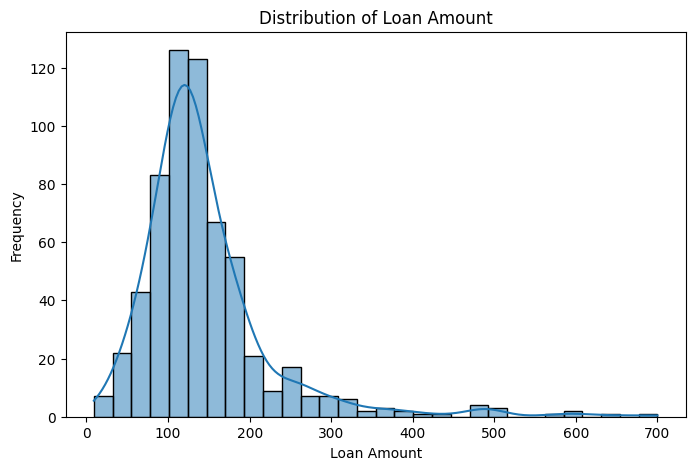

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["LoanAmount"],
             bins=30,
             kde=True)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

In [35]:
df["LoanAmount"].describe()

,LoanAmount
count,614.000000
mean,145.752443
std,84.107233
min,9.000000
25%,100.250000
50%,128.000000
75%,164.750000
max,700.000000


The Loan Amount variable is positively skewed. Most loans are concentrated between 100 and 200 units, while a small number of applicants requested significantly larger loans, resulting in high-value outliers.

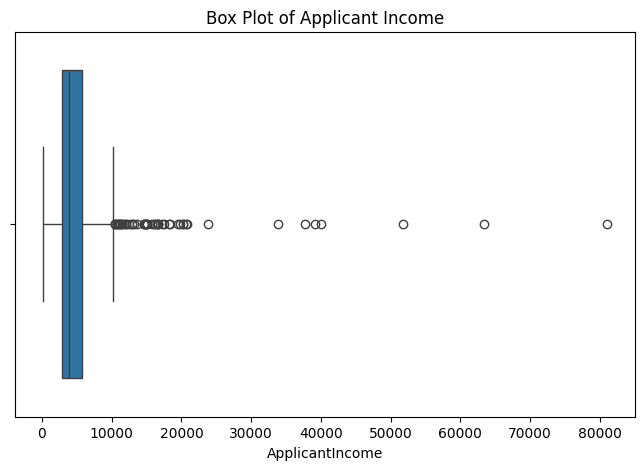

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["ApplicantIncome"])

plt.title("Box Plot of Applicant Income")

plt.show()

The Applicant Income feature contains several high-value outliers, indicating that while most applicants have moderate incomes, a small number report significantly higher earnings.

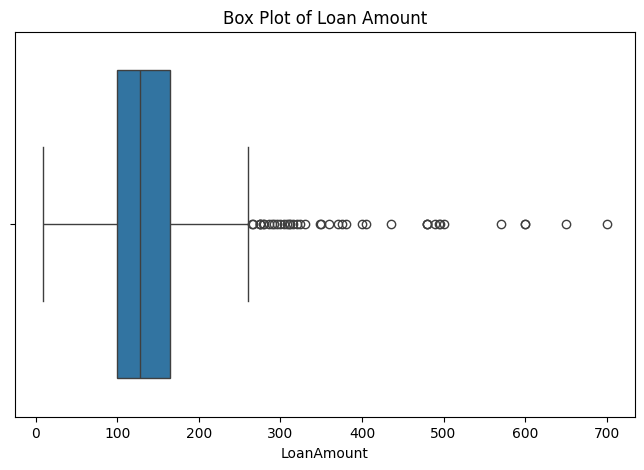

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["LoanAmount"])

plt.title("Box Plot of Loan Amount")

plt.show()

The Loan Amount feature also contains several high-value outliers. Most applicants requested moderate loan amounts, while a few requested substantially larger loans.

In [38]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [39]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (614, 11)
Target Shape: (614,)


In [40]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2


In [41]:
y.head()

,Loan_Status
0,1
1,0
2,1
3,1
4,1


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [43]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (491, 11)
X_test : (123, 11)
y_train: (491,)
y_test : (123,)


In [44]:
print("Training Set:")
print(y_train.value_counts())

print("\nTesting Set:")
print(y_test.value_counts())

Training Set:
Loan_Status
1    337
0    154
Name: count, dtype: int64

Testing Set:
Loan_Status
1    85
0    38
Name: count, dtype: int64


In [45]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [46]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (491, 11)
X_test_scaled shape: (123, 11)


In [47]:
X_train_scaled[:5]

array([[ 0.46405445, -1.38033526, -0.74858624, -0.54046763, -0.39407375,
        -0.352802  , -0.56322811, -1.13158849,  0.28069139,  0.39751587,
         1.22203919],
       [ 0.46405445,  0.72446168,  0.25020681, -0.54046763, -0.39407375,
        -0.3433464 , -0.56322811, -0.59230932,  0.28069139,  0.39751587,
        -0.04382841],
       [ 0.46405445,  0.72446168,  1.24899986, -0.54046763, -0.39407375,
        -0.33947116,  0.05040502,  0.04075753,  0.28069139, -2.51562283,
        -1.30969601],
       [ 0.46405445,  0.72446168,  0.25020681,  1.85024956, -0.39407375,
        -0.44596289, -0.02495343, -0.3930105 , -2.48676788, -2.51562283,
        -1.30969601],
       [ 0.46405445,  0.72446168, -0.74858624, -0.54046763, -0.39407375,
        -0.45107822,  0.23449496,  0.04075753,  0.28069139,  0.39751587,
        -0.04382841]])

In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{np.int64(0): np.float64(1.594155844155844), np.int64(1): np.float64(0.728486646884273)}


In [49]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(
    class_weight=class_weights,
    random_state=42,
    max_iter=1000
)


lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [50]:

y_pred = lr_model.predict(X_test_scaled)


y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed!")

Predictions completed!


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8048780487804879
Precision: 0.8426966292134831
Recall   : 0.8823529411764706
F1 Score : 0.8620689655172413
ROC AUC  : 0.8095975232198143

Confusion Matrix
[[24 14]
 [10 75]]

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.76      0.76       123
weighted avg       0.80      0.80      0.80       123



Class 0 (Rejected)

Precision = 0.71

Recall = 0.63

F1-score = 0.67


Class 1 (Approved)

Precision = 0.84

Recall = 0.88

F1-score = 0.86

The model performs much better at predicting approved loans, which is expected because there are more approved than rejected cases in the dataset.

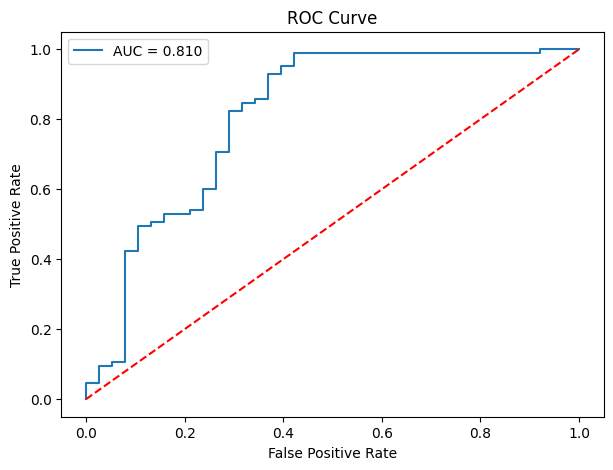

In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weights
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [54]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.8373983739837398
ROC AUC: 0.7959752321981424

Confusion Matrix
[[23 15]
 [ 5 80]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.61      0.70        38
           1       0.84      0.94      0.89        85

    accuracy                           0.84       123
   macro avg       0.83      0.77      0.79       123
weighted avg       0.84      0.84      0.83       123



Two machine learning models were trained for loan approval prediction: Logistic Regression and Random Forest. Logistic Regression achieved an accuracy of 80.49%, while Random Forest achieved 83.74%. Random Forest also obtained a higher Recall (94%) and F1-score (89%), making it more effective in identifying approved loan applications. Therefore, Random Forest was selected as the best-performing model for this dataset.